# IMU 텀블러 상태 감지 개발

텀블러 탑재 IMU 센서 데이터로 **이동 중 / 거치됨** 2단계 상태를 판별하는 알고리즘을 개발합니다.

**개발 흐름**
1. 시나리오 데이터 생성
2. 원시 센서 신호 시각화
3. 슬라이딩 윈도우 기반 특징 계산
4. 임계값 탐색 및 시각화
5. `detect_tumbler_state` 함수 확정
6. 전체 타임라인 검증
7. 확정 상수 요약

> **설계 근거**: 텀블러가 기구 옆에 거치되면 사용자가 운동 중이든 휴식 중이든 센서 출력은 중력(~1.0 g)·자이로(≈ 0)로 동일합니다. 따라서 '이동 중 vs 거치됨' 2단계만 구분합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque

# 그래프 기본 스타일
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. 시나리오 데이터 생성

**샘플레이트**: 50 Hz (초당 50회 측정)

| 구간 | 상태 | 지속 시간 | 특성 |
|------|------|----------|------|
| ① | 이동 중 | 3 s | accel 편차 큼, gyro 활성 |
| ② | 거치됨 | 4 s | accel ≈ 1.0 g, gyro ≈ 0 |
| ③ | 이동 중 | 2 s | accel 편차 큼, gyro 활성 |
| ④ | 거치됨 | 3 s | accel ≈ 1.0 g, gyro ≈ 0 |

**단위**: accel → g (1.0 g = 중력), gyro → rad/s

In [2]:
np.random.seed(42)
SAMPLE_RATE = 50  # Hz

# 시나리오 구간 정의: (상태, 지속시간(초))
segments = [
    ('moving',  3),
    ('settled', 4),
    ('moving',  2),
    ('settled', 3),
]

accel_magnitude = []
gyro_magnitude  = []
true_states     = []

for state, duration in segments:
    n = duration * SAMPLE_RATE
    if state == 'moving':
        # 이동 중: 중력 기준 진폭이 크게 변동, 자이로 활성
        accel = 1.0 + np.random.normal(0.0, 0.35, n)
        gyro  = np.abs(np.random.normal(1.2, 0.6,  n))
    else:
        # 거치됨: 중력(1.0 g)만 측정, 자이로 ≈ 0 (극소 센서 노이즈)
        accel = 1.0 + np.random.normal(0.0, 0.015, n)
        gyro  = np.abs(np.random.normal(0.0, 0.008, n))

    accel_magnitude.extend(accel)
    gyro_magnitude.extend(gyro)
    true_states.extend([state] * n)

accel_magnitude = np.array(accel_magnitude)
gyro_magnitude  = np.array(gyro_magnitude)
t = np.arange(len(accel_magnitude)) / SAMPLE_RATE

# 각 구간의 시작 시각 계산 (배경색 표시용)
segment_boundaries = []
cursor = 0
for state, duration in segments:
    segment_boundaries.append((cursor / SAMPLE_RATE, (cursor + duration * SAMPLE_RATE) / SAMPLE_RATE, state))
    cursor += duration * SAMPLE_RATE

print(f'총 샘플 수: {len(t)}')
print(f'총 시간   : {t[-1]:.1f} s')
print(f'이동 중   : {true_states.count("moving")} 샘플')
print(f'거치됨    : {true_states.count("settled")} 샘플')

총 샘플 수: 600
총 시간   : 12.0 s
이동 중   : 250 샘플
거치됨    : 350 샘플


## 2. 원시 센서 데이터 시각화

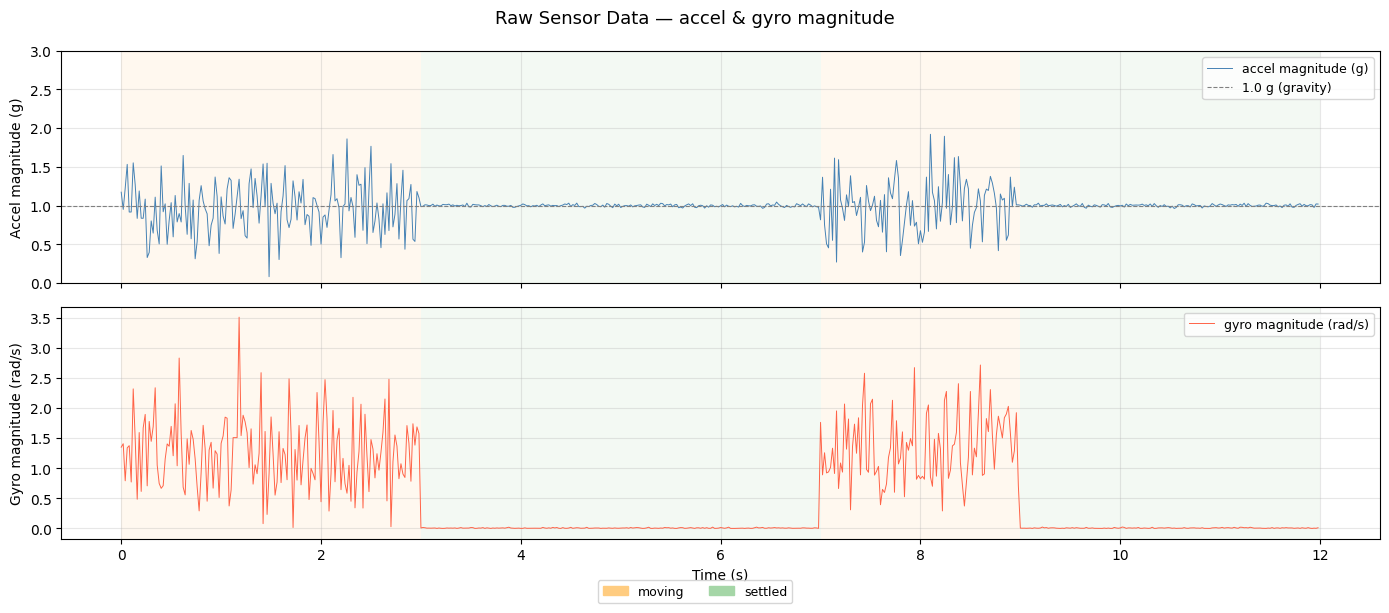

In [3]:
def shade_segments(ax, boundaries):
    """구간별 배경색: 이동 중=주황, 거치됨=초록"""
    for start, end, state in boundaries:
        color = '#fff3e0' if state == 'moving' else '#e8f5e9'
        ax.axvspan(start, end, alpha=0.5, color=color, linewidth=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle('Raw Sensor Data — accel & gyro magnitude', fontsize=13)

# accel magnitude
shade_segments(axes[0], segment_boundaries)
axes[0].plot(t, accel_magnitude, color='steelblue', linewidth=0.7, label='accel magnitude (g)')
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='1.0 g (gravity)')
axes[0].set_ylabel('Accel magnitude (g)')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_ylim(0, 3.0)

# gyro magnitude
shade_segments(axes[1], segment_boundaries)
axes[1].plot(t, gyro_magnitude, color='tomato', linewidth=0.7, label='gyro magnitude (rad/s)')
axes[1].set_ylabel('Gyro magnitude (rad/s)')
axes[1].set_xlabel('Time (s)')
axes[1].legend(loc='upper right', fontsize=9)

# 범례 패치
moving_patch  = mpatches.Patch(color='#ffcc80', label='moving')
settled_patch = mpatches.Patch(color='#a5d6a7', label='settled')
fig.legend(handles=[moving_patch, settled_patch], loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.02), fontsize=9)

plt.tight_layout()
plt.show()

## 3. 슬라이딩 윈도우 기반 특징 계산

순간 값은 노이즈에 취약합니다. 최근 N개 샘플의 **이동 평균(accel 편차)** 과 **분산(gyro)** 으로 안정적인 특징을 추출합니다.

- `accel_dev_mean`: 슬라이딩 윈도우 내 `|accel − 1.0 g|` 의 평균 → 클수록 이동 중
- `gyro_var`: 슬라이딩 윈도우 내 gyro 분산 → 클수록 이동 중

**윈도우 크기** 선택 근거: `WINDOW_SIZE = 20` → 50 Hz 기준 0.4 초, 충분히 반응적이면서 단발 노이즈에 강인.

In [4]:
WINDOW_SIZE = 20  # 샘플 수 (50 Hz × 0.4 s)

# accel 편차: 중력(1.0 g)으로부터의 절댓값 편차
accel_dev = np.abs(accel_magnitude - 1.0)

win_accel_dev_mean = np.zeros(len(t))
win_gyro_var       = np.zeros(len(t))

for i in range(len(t)):
    start = max(0, i - WINDOW_SIZE + 1)
    win_accel_dev_mean[i] = np.mean(accel_dev[start:i + 1])
    win_gyro_var[i]       = np.var(gyro_magnitude[start:i + 1])

print('--- 구간별 특징 통계 ---')
for seg_start, seg_end, state in segment_boundaries:
    idx = (t >= seg_start) & (t < seg_end)
    print(f'[{state:>8}]  accel_dev_mean: {win_accel_dev_mean[idx].mean():.4f} g'
          f'  |  gyro_var: {win_gyro_var[idx].mean():.4f} (rad/s)²')

--- 구간별 특징 통계 ---
[  moving]  accel_dev_mean: 0.2575 g  |  gyro_var: 0.3339 (rad/s)²
[ settled]  accel_dev_mean: 0.0243 g  |  gyro_var: 0.0399 (rad/s)²
[  moving]  accel_dev_mean: 0.2527 g  |  gyro_var: 0.3262 (rad/s)²
[ settled]  accel_dev_mean: 0.0231 g  |  gyro_var: 0.0604 (rad/s)²


## 4. 임계값 탐색 및 시각화

두 특징(`accel_dev_mean`, `gyro_var`)에 임계값을 적용하여 상태를 판별합니다.

**판별 규칙**: `accel_dev_mean > THRESH_ACCEL` **OR** `gyro_var > THRESH_GYRO` → 이동 중, 아니면 거치됨

In [5]:
# 탐색할 임계값 후보
accel_candidates = [0.04, 0.06, 0.08, 0.10, 0.12]
gyro_candidates  = [0.02, 0.05, 0.10, 0.20, 0.40]

true_moving = np.array([s == 'moving' for s in true_states])

print(f'{"THRESH_ACCEL":>14} | {"THRESH_GYRO":>12} | {"Accuracy":>10} | {"False Moving":>13} | {"Missed Moving":>14}')
print('-' * 72)

best_acc, best_combo = 0.0, (None, None)

for ta in accel_candidates:
    for tg in gyro_candidates:
        pred_moving = (win_accel_dev_mean > ta) | (win_gyro_var > tg)
        acc = np.mean(pred_moving == true_moving)
        false_moving  = np.mean(pred_moving & ~true_moving)   # 거치됨인데 이동 중으로 예측
        missed_moving = np.mean(~pred_moving & true_moving)   # 이동 중인데 거치됨으로 예측
        print(f'{ta:>14.2f} | {tg:>12.2f} | {acc:>10.4f} | {false_moving:>13.4f} | {missed_moving:>14.4f}')
        if acc > best_acc:
            best_acc, best_combo = acc, (ta, tg)

print(f'\n최적 조합: THRESH_ACCEL={best_combo[0]}, THRESH_GYRO={best_combo[1]}, Accuracy={best_acc:.4f}')

  THRESH_ACCEL |  THRESH_GYRO |   Accuracy |  False Moving |  Missed Moving
------------------------------------------------------------------------
          0.04 |         0.02 |     0.9367 |        0.0633 |         0.0000
          0.04 |         0.05 |     0.9383 |        0.0617 |         0.0000
          0.04 |         0.10 |     0.9383 |        0.0617 |         0.0000
          0.04 |         0.20 |     0.9383 |        0.0583 |         0.0033
          0.04 |         0.40 |     0.9450 |        0.0517 |         0.0033
          0.06 |         0.02 |     0.9367 |        0.0633 |         0.0000
          0.06 |         0.05 |     0.9383 |        0.0617 |         0.0000
          0.06 |         0.10 |     0.9383 |        0.0617 |         0.0000
          0.06 |         0.20 |     0.9383 |        0.0583 |         0.0033
          0.06 |         0.40 |     0.9450 |        0.0500 |         0.0050
          0.08 |         0.02 |     0.9367 |        0.0633 |         0.0000
          0.08 

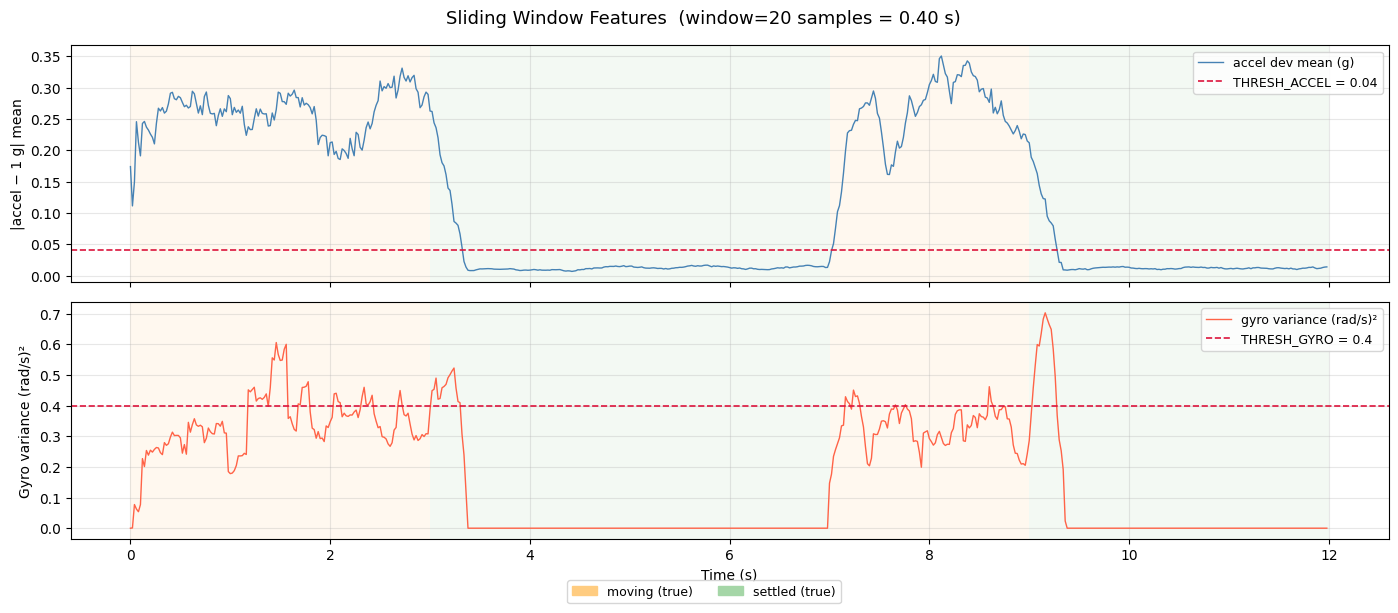

In [6]:
# 최적 임계값으로 슬라이딩 윈도우 특징과 임계선 시각화
MOVE_ACCEL_THRESHOLD = best_combo[0]
MOVE_GYRO_VAR        = best_combo[1]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle(f'Sliding Window Features  (window={WINDOW_SIZE} samples = {WINDOW_SIZE/SAMPLE_RATE:.2f} s)', fontsize=13)

# accel 편차 이동 평균
shade_segments(axes[0], segment_boundaries)
axes[0].plot(t, win_accel_dev_mean, color='steelblue', linewidth=1.0, label='accel dev mean (g)')
axes[0].axhline(MOVE_ACCEL_THRESHOLD, color='crimson', linestyle='--', linewidth=1.2,
                label=f'THRESH_ACCEL = {MOVE_ACCEL_THRESHOLD}')
axes[0].set_ylabel('|accel − 1 g| mean')
axes[0].legend(loc='upper right', fontsize=9)

# gyro 분산
shade_segments(axes[1], segment_boundaries)
axes[1].plot(t, win_gyro_var, color='tomato', linewidth=1.0, label='gyro variance (rad/s)²')
axes[1].axhline(MOVE_GYRO_VAR, color='crimson', linestyle='--', linewidth=1.2,
                label=f'THRESH_GYRO = {MOVE_GYRO_VAR}')
axes[1].set_ylabel('Gyro variance (rad/s)²')
axes[1].set_xlabel('Time (s)')
axes[1].legend(loc='upper right', fontsize=9)

moving_patch  = mpatches.Patch(color='#ffcc80', label='moving (true)')
settled_patch = mpatches.Patch(color='#a5d6a7', label='settled (true)')
fig.legend(handles=[moving_patch, settled_patch], loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.02), fontsize=9)

plt.tight_layout()
plt.show()

## 5. 최종 상태 감지 함수 확정

위 탐색 결과를 기반으로 `detect_tumbler_state` 함수를 정의합니다.
이 함수가 `backend/pipeline/imu_state.py` 에 그대로 이식됩니다.

In [7]:
from dataclasses import dataclass
from typing import Literal

# ── 확정 상수 ─────────────────────────────────────────────────────────────────
WINDOW_SIZE          = 20    # 슬라이딩 윈도우 크기 (샘플 수, 50 Hz 기준 0.4 s)
MOVE_ACCEL_THRESHOLD = MOVE_ACCEL_THRESHOLD  # |accel − 1 g| 이동 평균 임계값 (g)
MOVE_GYRO_VAR        = MOVE_GYRO_VAR         # gyro 분산 임계값 (rad/s)²

TumblerState = Literal['moving', 'settled']

@dataclass
class SensorReading:
    # 가속도 크기 (g 단위, 정지 시 ≈ 1.0 g)
    accel_magnitude: float
    # 자이로 크기 (rad/s, 정지 시 ≈ 0)
    gyro_magnitude: float


def detect_tumbler_state(sensor_window: deque) -> TumblerState:
    """
    슬라이딩 윈도우 내 센서 값으로 텀블러 상태를 판별한다.

    - moving : |accel − 1 g| 평균 > THRESH  또는  gyro 분산 > THRESH
    - settled: 두 조건 모두 임계값 이하
    """
    if len(sensor_window) == 0:
        return 'moving'

    readings = list(sensor_window)

    # 중력(1.0 g) 기준 편차 이동 평균
    accel_dev_mean = np.mean([abs(r.accel_magnitude - 1.0) for r in readings])

    # gyro 분산
    gyro_values = [r.gyro_magnitude for r in readings]
    gyro_var    = np.var(gyro_values)

    if accel_dev_mean > MOVE_ACCEL_THRESHOLD or gyro_var > MOVE_GYRO_VAR:
        return 'moving'
    return 'settled'


print('detect_tumbler_state 함수 정의 완료')
print(f'  WINDOW_SIZE          = {WINDOW_SIZE}')
print(f'  MOVE_ACCEL_THRESHOLD = {MOVE_ACCEL_THRESHOLD}')
print(f'  MOVE_GYRO_VAR        = {MOVE_GYRO_VAR}')

detect_tumbler_state 함수 정의 완료
  WINDOW_SIZE          = 20
  MOVE_ACCEL_THRESHOLD = 0.04
  MOVE_GYRO_VAR        = 0.4


## 6. 전체 타임라인 검증

원시 시나리오 데이터를 샘플 단위로 순회하며 `detect_tumbler_state` 를 호출하고,
예측 결과를 실제 레이블과 비교합니다.

In [8]:
sensor_window = deque(maxlen=WINDOW_SIZE)
predicted_states = []

for accel, gyro in zip(accel_magnitude, gyro_magnitude):
    sensor_window.append(SensorReading(accel_magnitude=accel, gyro_magnitude=gyro))
    state = detect_tumbler_state(sensor_window)
    predicted_states.append(state)

predicted_states = np.array(predicted_states)
true_arr         = np.array(true_states)

accuracy = np.mean(predicted_states == true_arr)
print(f'전체 정확도: {accuracy:.4f} ({accuracy*100:.2f} %)')

# 구간별 정확도
print('\n--- 구간별 정확도 ---')
for seg_start, seg_end, state in segment_boundaries:
    idx = (t >= seg_start) & (t < seg_end)
    seg_acc = np.mean(predicted_states[idx] == true_arr[idx])
    print(f'  [{state:>8}]  {seg_start:.1f}s ~ {seg_end:.1f}s : {seg_acc:.4f}')

전체 정확도: 0.9450 (94.50 %)

--- 구간별 정확도 ---
  [  moving]  0.0s ~ 3.0s : 1.0000
  [ settled]  3.0s ~ 7.0s : 0.9150
  [  moving]  7.0s ~ 9.0s : 0.9800
  [ settled]  9.0s ~ 12.0s : 0.9067


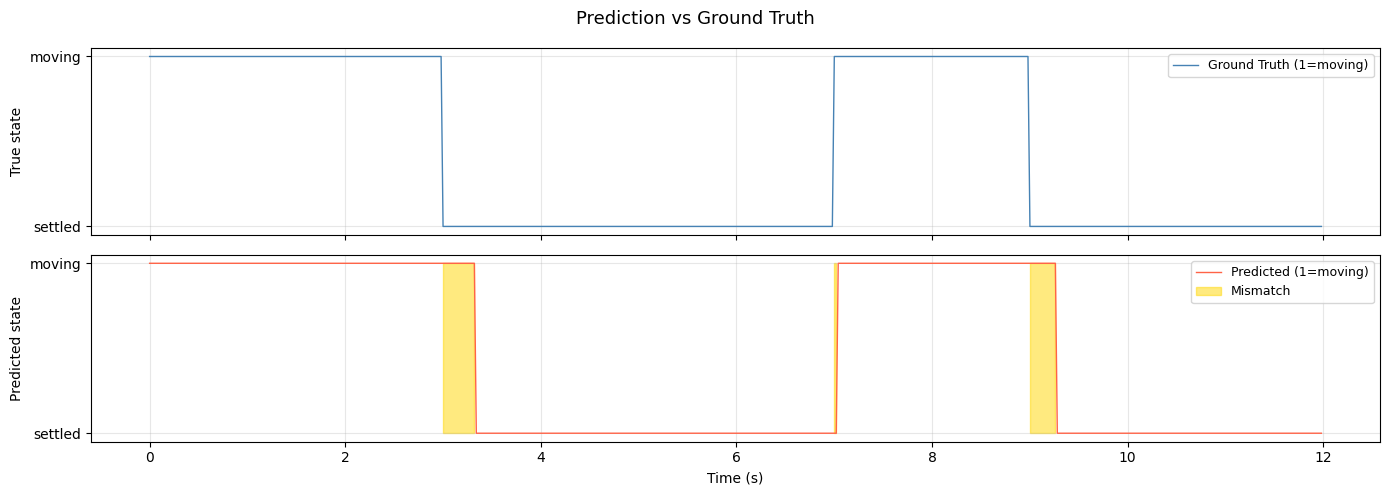

오분류 구간: 33 샘플 (660 ms)
  → 대부분 슬라이딩 윈도우가 채워지는 전환 직후 구간 (약 WINDOW_SIZE / SAMPLE_RATE = 400 ms) 에 집중됩니다.


In [9]:
# 예측 vs 실제 시각화
pred_numeric = (predicted_states == 'moving').astype(int)
true_numeric = (true_arr == 'moving').astype(int)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
fig.suptitle('Prediction vs Ground Truth', fontsize=13)

axes[0].plot(t, true_numeric,  color='steelblue', linewidth=1.0, label='Ground Truth (1=moving)')
axes[0].set_ylabel('True state')
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['settled', 'moving'])
axes[0].legend(loc='upper right', fontsize=9)

axes[1].plot(t, pred_numeric, color='tomato',    linewidth=1.0, label='Predicted (1=moving)')
axes[1].set_ylabel('Predicted state')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['settled', 'moving'])
axes[1].set_xlabel('Time (s)')
axes[1].legend(loc='upper right', fontsize=9)

# 오분류 구간 표시
mismatch = pred_numeric != true_numeric
if mismatch.any():
    axes[1].fill_between(t, 0, 1, where=mismatch, color='gold', alpha=0.5, label='Mismatch')
    axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

mismatch_ms = mismatch.sum() / SAMPLE_RATE * 1000
print(f'오분류 구간: {mismatch.sum()} 샘플 ({mismatch_ms:.0f} ms)')
print('  → 대부분 슬라이딩 윈도우가 채워지는 전환 직후 구간 (약 WINDOW_SIZE / SAMPLE_RATE = '
      f'{WINDOW_SIZE / SAMPLE_RATE * 1000:.0f} ms) 에 집중됩니다.')

## 7. 확정 상수 요약

아래 값을 `backend/pipeline/imu_state.py` 의 상수로 사용합니다.

In [10]:
print('=' * 50)
print('  imu_state.py 이식 상수')
print('=' * 50)
print(f'  WINDOW_SIZE          = {WINDOW_SIZE}')
print(f'  MOVE_ACCEL_THRESHOLD = {MOVE_ACCEL_THRESHOLD}')
print(f'  MOVE_GYRO_VAR        = {MOVE_GYRO_VAR}')
print('=' * 50)

  imu_state.py 이식 상수
  WINDOW_SIZE          = 20
  MOVE_ACCEL_THRESHOLD = 0.04
  MOVE_GYRO_VAR        = 0.4
